In [2]:
hi = 0

In [21]:
print("HI")

HI


In [9]:
import struct
from pathlib import Path

filename = "./images/yard.bmp"

In [11]:
with open(filename, "rb") as f:
    data = bytearray(f.read())

print("File size:", len(data), "bytes")

File size: 720056 bytes


In [12]:
print(data[:14])


bytearray(b'BM\xb8\xfc\n\x00\x00\x00\x00\x006\x00\x00\x00')


In [14]:
print(" ".join(f"{x:02X}" for x in data[:14]))

42 4D B8 FC 0A 00 00 00 00 00 36 00 00 00


In [15]:
file_size = struct.unpack_from("<I", data, 2)[0]
pixel_offset = struct.unpack_from("<I", data, 10)[0]

width = struct.unpack_from("<i", data, 18)[0]
height = struct.unpack_from("<i", data, 22)[0]
bits_per_pixel = struct.unpack_from("<H", data, 28)[0]

print("File size:", file_size)
print("Pixel data starts at:", pixel_offset)
print("Width:", width)
print("Height:", height)
print("Bits per pixel:", bits_per_pixel)

File size: 720056
Pixel data starts at: 54
Width: 600
Height: -400
Bits per pixel: 24


In [16]:
pixel_offset = pixel_offset

b = data[pixel_offset]
g = data[pixel_offset + 1]
r = data[pixel_offset + 2]

print("R:", r)
print("G:", g)
print("B:", b)


R: 85
G: 50
B: 56


In [20]:
data[pixel_offset] = 0       # B
data[pixel_offset + 1] = 0   # G
data[pixel_offset + 2] = 0 # R

In [22]:
with open("modified.bmp", "wb") as f:
    f.write(data)

print("Saved modified.bmp")

Saved modified.bmp


In [25]:
from PIL import Image

img = Image.open("./images/yard.bmp")

print("Size:", img.size)
print("Mode:", img.mode)

display(img)

ModuleNotFoundError: No module named 'PIL'

In [26]:
%pip install Pillow


803.18s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


/home/kisuke-34/coding/my-dev-env/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
%pip install Pillow

/home/kisuke-34/coding/my-dev-env/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from PIL import Image

img = Image.open("./images/yard.bmp")

print("Size:", img.size)
print("Mode:", img.mode)

display(img)

ModuleNotFoundError: No module named 'PIL'

In [3]:
import sys
print(sys.executable)

/home/kisuke-34/coding/my-dev-env/bin/python


In [4]:
import sys
!{sys.executable} -m pip install Pillow

/home/kisuke-34/coding/my-dev-env/bin/python: No module named pip


In [5]:
!{sys.executable} -m ensurepip --upgrade

Looking in links: /tmp/tmpv14id_0b
Processing /tmp/tmpv14id_0b/pip-25.2-py3-none-any.whl


In [6]:
!{sys.executable} -m pip install Pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 5.9 MB/s  0:00:01m 6.1 MB/s eta 0:00:01

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


(600, 400)


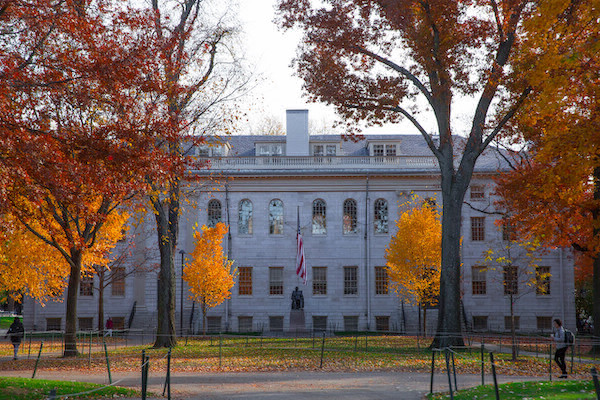

In [7]:
from PIL import Image

img = Image.open("./images/yard.bmp")
print(img.size)
display(img)

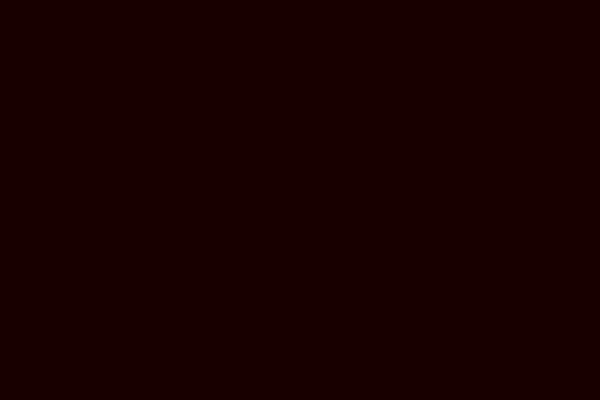

In [10]:
pixels = img.load()

width, height = img.size

# Change the top-left quarter to red
for y in range(height):
    for x in range(width):
        pixels[x, y] = (25, 0, 0)

display(img)